# Loss Distribution of a Delta-Hedged Short Put
## Full, linearized and second-order loss operators, by Monte Carlo

**Notebook:** `loss_homework.ipynb`
**Repository:** <https://github.com/zhuchenpop-afk/MF731/blob/main/loss_homework.ipynb>

---

### What this notebook does

A portfolio is short $M$ European put options and long $M\lambda$ shares of the
underlying, where $\lambda=\delta(t,S_t)$ is the option delta frozen at time $t$.
The notebook

1. implements the Black–Scholes put price and its three greeks;
2. implements the **full**, **linearized** and **second-order** loss operators
   derived in section 4, as functions of the log return $x=X_{t+\Delta}$;
3. simulates $N=100{,}000$ log returns and builds histogram approximations of the
   three loss densities;
4. compares the approximations — where they agree, where they fail, and what that
   does to the risk numbers.

### Requirements

Python ≥ 3.9 with `numpy`, `scipy` and `matplotlib`. No market data and no network
access are needed: every input is a parameter.

```bash
pip install -r requirements.txt
```

### How to run it in VS Code

Open the notebook, click **Select Kernel**, choose your Python interpreter, and
press **Run All**. It takes a few seconds.

### Files produced

```
loss_operators.png        the three loss operators as functions of x
loss_distributions.png    histogram approximations of the three loss densities
```

---
## 1. Package imports

In [1]:
import sys

_REQUIRED = {"numpy": "numpy", "scipy": "scipy", "matplotlib": "matplotlib"}
_missing = []
for _mod, _pkg in _REQUIRED.items():
    try:
        __import__(_mod)
    except ImportError:
        _missing.append(_pkg)
if _missing:
    raise ImportError(
        "Missing package(s): " + ", ".join(_missing) + "\n"
        "Install with:\n    pip install " + " ".join(_missing)
    )

from pathlib import Path

import numpy as np
import scipy
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("scipy      ", scipy.__version__)
print("matplotlib ", matplotlib.__version__)

python      3.11.15
numpy       2.4.4
scipy       1.17.1
matplotlib  3.10.9


---
## 2. Parameters

| Symbol | Meaning | Value |
|---|---|---|
| $\mu$ | drift of the stock under the physical measure $\mathbb P$ | $0.16905$ |
| $\sigma$ | volatility | $0.4907$ |
| $r$ | risk-free rate | $0.0011888$ |
| $t$ | current time | $0$ |
| $T$ | option maturity | $0.291667$ |
| $\Delta$ | risk horizon (ten trading days) | $10/252$ |
| $S_0$ | current stock price | $152.51$ |
| $K$ | strike | $170$ |
| $M$ | number of puts sold | $100$ |
| $N$ | Monte-Carlo trials | $100{,}000$ |

A fixed seed is set so that re-running the notebook reproduces exactly the same
$100{,}000$ draws and therefore the same figures and numbers.

In [2]:
MU      = 0.16905        # physical drift
SIGMA   = 0.4907         # volatility
R       = 0.0011888      # risk-free rate
T_NOW   = 0.0            # t
T_MAT   = 0.291667       # T
DELTA   = 10.0 / 252.0   # risk horizon
S0      = 152.51         # S_t
K       = 170.0          # strike
M_OPT   = 100            # number of put options sold
N_SIM   = 100_000        # Monte-Carlo trials
SEED    = 731

TAU_0   = T_MAT - T_NOW            # time to maturity at t
TAU_1   = T_MAT - (T_NOW + DELTA)  # time to maturity at t + Delta

FIG1 = Path("loss_operators.png")
FIG2 = Path("loss_distributions.png")

# colour-blind-safe, print-friendly
C_FULL, C_LIN, C_QUAD = "#2a78d6", "#eb6834", "#4a3aa7"
C_INK, C_MUTE = "#0b0b0b", "#8a8a85"
FIG_DPI = 200

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": FIG_DPI, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 11, "legend.frameon": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

assert TAU_1 > 0, "the risk horizon must end before maturity"
print(f"tau at t        = {TAU_0:.8f} years")
print(f"tau at t+Delta  = {TAU_1:.8f} years   (Delta = {DELTA:.8f})")
print(f"N = {N_SIM:,} trials, seed = {SEED}")

tau at t        = 0.29166700 years
tau at t+Delta  = 0.25198446 years   (Delta = 0.03968254)
N = 100,000 trials, seed = 731


---
## 3. Black–Scholes put price and greeks

$$P^{BS}(t,x)=x\bigl(N(d_1(T-t,x))-1\bigr)+Ke^{-r(T-t)}\bigl(1-N(d_2(T-t,x))\bigr),$$

$$d_1(\tau,x)=\frac{1}{\sigma\sqrt\tau}\left(\log\frac{x}{K}+\Bigl(r+\tfrac12\sigma^2\Bigr)\tau\right),
\qquad d_2(\tau,x)=d_1-\sigma\sqrt\tau,$$

with greeks

$$\delta(t,x)=\partial_xP^{BS}=N(d_1)-1,\qquad
\gamma(t,x)=\partial_{xx}P^{BS}=\frac{\varphi(d_1)}{x\sigma\sqrt{T-t}},$$

$$\theta(t,x)=\partial_tP^{BS}=-\frac{\sigma}{2\sqrt{T-t}}\,x\,\varphi(d_1)
+Kre^{-r(T-t)}\bigl(1-N(d_2)\bigr).$$

**A note on the price formula.** The assignment sheet prints
$x\bigl(N(d_1)-2\bigr)$ in the first term. That is a typographical slip: with $-2$
the price would be $-125.41$ at the given parameters, which is impossible for a
put, and it would contradict the delta $\delta=N(d_1)-1$ stated three lines below
it. The correct coefficient is $-1$, which is the standard form
$Ke^{-r\tau}N(-d_2)-xN(-d_1)$. The cell below verifies this three ways: against
that standard form, against a Monte-Carlo evaluation of the risk-neutral
expectation $\mathbb E^{\mathbb Q}[e^{-r(T-t)}(K-S_T)^+]$, and by checking that
the three given greek formulas really are the derivatives of the price.

In [3]:
def d1d2(tau, x):
    """The Black-Scholes d1 and d2 at time-to-maturity tau and spot x."""
    tau = np.asarray(tau, dtype=float)
    x = np.asarray(x, dtype=float)
    d1 = (np.log(x / K) + (R + 0.5 * SIGMA ** 2) * tau) / (SIGMA * np.sqrt(tau))
    return d1, d1 - SIGMA * np.sqrt(tau)


def put_price(tau, x):
    """P^BS: x (N(d1) - 1) + K e^{-r tau} (1 - N(d2))."""
    d1, d2 = d1d2(tau, x)
    return x * (norm.cdf(d1) - 1.0) + K * np.exp(-R * tau) * (1.0 - norm.cdf(d2))


def put_delta(tau, x):
    """delta = N(d1) - 1."""
    return norm.cdf(d1d2(tau, x)[0]) - 1.0


def put_gamma(tau, x):
    """gamma = phi(d1) / (x sigma sqrt(tau))."""
    d1, _ = d1d2(tau, x)
    return norm.pdf(d1) / (x * SIGMA * np.sqrt(tau))


def put_theta(tau, x):
    """theta = -(sigma / (2 sqrt(tau))) x phi(d1) + K r e^{-r tau} (1 - N(d2))."""
    d1, d2 = d1d2(tau, x)
    return (-SIGMA / (2.0 * np.sqrt(tau)) * x * norm.pdf(d1)
            + K * R * np.exp(-R * tau) * (1.0 - norm.cdf(d2)))


# ---------------------------------------------------- values at (t, S0)
P0     = float(put_price(TAU_0, S0))
LAMBDA = float(put_delta(TAU_0, S0))       # lambda = delta(t, S_t), frozen over [t, t+Delta]
GAMMA0 = float(put_gamma(TAU_0, S0))
THETA0 = float(put_theta(TAU_0, S0))
_d1, _d2 = d1d2(TAU_0, S0)

print(f"d1 = {float(_d1): .8f}    N(d1) = {float(norm.cdf(_d1)):.8f}")
print(f"d2 = {float(_d2): .8f}    N(d2) = {float(norm.cdf(_d2)):.8f}")
print(f"P^BS(t, S0) = {P0: .8f}")
print(f"lambda      = {LAMBDA: .8f}")
print(f"gamma       = {GAMMA0: .8f}")
print(f"theta       = {THETA0: .8f}")

V_T = M_OPT * (LAMBDA * S0 - P0)
print(f"\nV_t = M(lambda S_t - P^BS(t,S_t)) = {V_T:.6f}")

d1 = -0.27586593    N(d1) = 0.39132552
d2 = -0.54087437    N(d2) = 0.29429709
P^BS(t, S0) =  27.09895988
lambda      = -0.60867448
gamma       =  0.00950226
theta       = -26.46624019

V_t = M(lambda S_t - P^BS(t,S_t)) = -11992.790447


In [4]:
# ------------------------------------------------- verification of the price formula
print("VERIFICATION 1 - the price formula")
textbook = K * np.exp(-R * TAU_0) * norm.cdf(-_d2) - S0 * norm.cdf(-_d1)
as_printed = S0 * (norm.cdf(_d1) - 2.0) + K * np.exp(-R * TAU_0) * (1.0 - norm.cdf(_d2))
print(f"  with (N(d1) - 1)               : {P0:.6f}")
print(f"  K e^-r.tau N(-d2) - S N(-d1)   : {float(textbook):.6f}")
print(f"  with (N(d1) - 2), as printed   : {float(as_printed):.6f}   <- impossible for a put")
print(f"  intrinsic (K - S0)^+           : {max(K - S0, 0.0):.6f}   (a lower bound, up to discounting)")
assert abs(P0 - float(textbook)) < 1e-10

rng_chk = np.random.default_rng(0)
ST = S0 * np.exp((R - 0.5 * SIGMA ** 2) * TAU_0
                 + SIGMA * np.sqrt(TAU_0) * rng_chk.standard_normal(2_000_000))
disc = np.exp(-R * TAU_0) * np.maximum(K - ST, 0.0)
mc, se = disc.mean(), disc.std(ddof=1) / np.sqrt(disc.size)
print(f"  MC of E^Q[e^-r.tau (K - S_T)^+]: {mc:.4f}  +/- {1.96*se:.4f}  (95% CI)")
assert abs(mc - P0) < 4 * se + 1e-9

print("\nVERIFICATION 2 - the given greeks are the derivatives of that price")
h = 1e-2
fd_delta = (put_price(TAU_0, S0 + h) - put_price(TAU_0, S0 - h)) / (2 * h)
fd_gamma = (put_price(TAU_0, S0 + h) - 2 * put_price(TAU_0, S0)
            + put_price(TAU_0, S0 - h)) / h ** 2
ht = 1e-6
fd_theta = (put_price(TAU_0 - ht, S0) - put_price(TAU_0 + ht, S0)) / (2 * ht)
for nm, fd, given in (("delta", fd_delta, LAMBDA), ("gamma", fd_gamma, GAMMA0),
                      ("theta", fd_theta, THETA0)):
    rel = abs(float(fd) / given - 1.0)
    print(f"  {nm:<6} finite difference {float(fd): .8f}   formula {given: .8f}   rel. diff {rel:.2e}")
    assert rel < 1e-5
print("\n  the '-2' in the assignment is a typo for '-1'  (confirmed)")

VERIFICATION 1 - the price formula
  with (N(d1) - 1)               : 27.098960
  K e^-r.tau N(-d2) - S N(-d1)   : 27.098960
  with (N(d1) - 2), as printed   : -125.411040   <- impossible for a put
  intrinsic (K - S0)^+           : 17.490000   (a lower bound, up to discounting)
  MC of E^Q[e^-r.tau (K - S_T)^+]: 27.0745  +/- 0.0361  (95% CI)

VERIFICATION 2 - the given greeks are the derivatives of that price
  delta  finite difference -0.60867448   formula -0.60867448   rel. diff 6.92e-11
  gamma  finite difference  0.00950225   formula  0.00950226   rel. diff 4.12e-08
  theta  finite difference -26.46624019   formula -26.46624019   rel. diff 2.84e-10

  the '-2' in the assignment is a typo for '-1'  (confirmed)


---
## 4. The three loss operators

### Setting up

The risk factor is the log price, $Z_t=z_t=\ln S_t$, so the risk factor change over
$[t,t+\Delta]$ is the log return

$$X_{t+\Delta}=z_{t+\Delta}-z_t=\ln\frac{S_{t+\Delta}}{S_t}=:x,
\qquad\text{i.e.}\qquad S_{t+\Delta}=S_te^{x}.$$

The portfolio value is a function of $(t,z)$:

$$V_t=f(t,z_t),\qquad
\boxed{\;f(t,z)=M\bigl(\lambda e^{z}-P^{BS}(t,e^{z})\bigr)\;}$$

with $\lambda=\delta(t,S_t)$ held **constant** over the horizon. The loss is
$L_{t+\Delta}=-(V_{t+\Delta}-V_t)$.

### Full loss operator

$$\ell_{[t]}(x)=-\bigl(f(t+\Delta,z_t+x)-f(t,z_t)\bigr)$$

$$\boxed{\;\ell_{[t]}(x)=M\Bigl(P^{BS}(t+\Delta,S_te^{x})-P^{BS}(t,S_t)
-\lambda S_t\bigl(e^{x}-1\bigr)\Bigr)\;}$$

The short put contributes the change in the option price, and the stock position
contributes $-\lambda S_t(e^x-1)$.

### Linearized loss operator

$$\ell^{\mathrm{lin}}_{[t]}(x)=-\bigl(\partial_tf(t,z_t)\Delta+\partial_zf(t,z_t)\,x\bigr).$$

The two partial derivatives are, writing $S=e^{z}$,

$$\partial_tf(t,z)=-M\,\partial_tP^{BS}(t,S)=-M\,\theta(t,S),$$

$$\partial_zf(t,z)=M\Bigl(\lambda e^{z}-\partial_xP^{BS}(t,e^{z})\,e^{z}\Bigr)
=M\,S\bigl(\lambda-\delta(t,S)\bigr).$$

Evaluated at $z=z_t$, where $S=S_t$ and $\delta(t,S_t)=\lambda$ **by construction of
the hedge**, the second derivative vanishes:

$$\partial_zf(t,z_t)=M\,S_t\bigl(\lambda-\lambda\bigr)=0 .$$

So the $x$ term disappears entirely and

$$\boxed{\;\ell^{\mathrm{lin}}_{[t]}(x)=M\,\Delta\,\theta(t,S_t)\quad\text{— a constant, independent of }x\;}$$

That is the "cool answer": **the linearized loss of a delta-hedged portfolio carries
no risk at all.** Its distribution is a point mass at $M\Delta\theta(t,S_t)$, its
variance is zero, and $\mathrm{VaR}_\alpha$ equals that same number for every
$\alpha$. This is exactly what delta-hedging is for — it removes the first-order
exposure — and it is also precisely why a linear approximation is useless for
measuring the risk of an option book.

### Second-order loss operator

Keeping the second derivative in $x$ only, as the assignment instructs (dropping
$\partial_{tt}f$ and $\partial_{tz}f$),

$$\ell^{\mathrm{quad}}_{[t]}(x)
=-\Bigl(\partial_tf(t,z_t)\Delta+\partial_zf(t,z_t)x+\tfrac12\partial_{zz}f(t,z_t)x^2\Bigr).$$

For the second $z$-derivative, differentiate $g(z)=P^{BS}(t,e^z)$ twice:

$$g'(z)=\delta\,e^{z},\qquad
g''(z)=\gamma\,e^{2z}+\delta\,e^{z},$$

so that

$$\partial_{zz}f(t,z)=M\Bigl(\lambda e^{z}-\gamma e^{2z}-\delta e^{z}\Bigr)
=M\,S\bigl(\lambda-\delta\bigr)-M\gamma S^{2}
\;\xrightarrow[\;z=z_t\;]{}\;-M\,\gamma(t,S_t)\,S_t^{2}.$$

Therefore

$$\boxed{\;\ell^{\mathrm{quad}}_{[t]}(x)
=M\Bigl(\Delta\,\theta(t,S_t)+\tfrac12\,\gamma(t,S_t)\,S_t^{2}\,x^{2}\Bigr)\;}$$

This is the familiar theta–gamma decomposition. Being short the put means being
short gamma, so $\gamma>0$ enters the **loss** with a positive sign: a move of
either sign costs money, quadratically. The constant $M\Delta\theta$ is the time
decay collected on the short position.

### Pseudocode — the loss operators

```
INPUT : parameters of the model and the option; the frozen hedge ratio lambda
OUTPUT: three functions of the log return x

full(x):
 1   S_new  <- S_t * exp(x)                        the stock price after the move
 2   P_new  <- put price at the later date, at S_new, one horizon closer to maturity
 3   return M * ( P_new - P_old - lambda * S_t * (exp(x) - 1) )

linearized(x):
 4   return M * Delta * theta                      no x appears: the hedge cancels it

second_order(x):
 5   return M * ( Delta * theta + 0.5 * gamma * S_t^2 * x^2 )
```

In [5]:
def loss_full(x):
    """Full loss operator: M ( P(t+Delta, S_t e^x) - P(t, S_t) - lambda S_t (e^x - 1) )."""
    x = np.asarray(x, dtype=float)
    s_new = S0 * np.exp(x)
    return M_OPT * (put_price(TAU_1, s_new) - P0 - LAMBDA * S0 * (np.exp(x) - 1.0))


def loss_linear(x):
    """Linearized loss operator: the constant M Delta theta (broadcast to x's shape)."""
    x = np.asarray(x, dtype=float)
    return np.full(x.shape, M_OPT * DELTA * THETA0)


def loss_quadratic(x):
    """Second-order loss operator: M ( Delta theta + 0.5 gamma S_t^2 x^2 )."""
    x = np.asarray(x, dtype=float)
    return M_OPT * (DELTA * THETA0 + 0.5 * GAMMA0 * S0 ** 2 * x ** 2)


L_LIN_CONST = M_OPT * DELTA * THETA0
print(f"linearized loss (constant)      = {L_LIN_CONST:.6f}")
print(f"  = M * Delta * theta = {M_OPT} * {DELTA:.8f} * {THETA0:.6f}")
print(f"quadratic curvature coefficient = {0.5 * M_OPT * GAMMA0 * S0 ** 2:.6f}  per unit x^2")

print("\nthe three operators at a few log returns:")
print(f"  {'x':>8}{'full':>14}{'linearized':>14}{'quadratic':>14}")
for _x in (-0.20, -0.10, -0.05, -0.02, 0.0, 0.02, 0.05, 0.10, 0.20):
    print(f"  {_x:>8.2f}{float(loss_full(_x)):>14.4f}"
          f"{float(loss_linear(_x)):>14.4f}{float(loss_quadratic(_x)):>14.4f}")

linearized loss (constant)      = -105.024763
  = M * Delta * theta = 100 * 0.03968254 * -26.466240
quadratic curvature coefficient = 11050.790469  per unit x^2

the three operators at a few log returns:
         x          full    linearized     quadratic
     -0.20      295.8665     -105.0248      337.0069
     -0.10       18.2447     -105.0248        5.4831
     -0.05      -69.0295     -105.0248      -77.3978
     -0.02      -98.9876     -105.0248     -100.6044
      0.00     -108.2538     -105.0248     -105.0248
      0.02     -108.2191     -105.0248     -100.6044
      0.05      -89.4288     -105.0248      -77.3978
      0.10       -3.7145     -105.0248        5.4831
      0.20      393.8501     -105.0248      337.0069


In [6]:
# ---------------------------------------------- checks on the derivation
print("CHECK 1 - the hedge really does kill the first-order term")
dz = 1e-5
f = lambda z: M_OPT * (LAMBDA * np.exp(z) - put_price(TAU_0, np.exp(z)))
z_t = np.log(S0)
fz = (f(z_t + dz) - f(z_t - dz)) / (2 * dz)
print(f"  d f / d z at z_t (numerical) = {float(fz): .6e}   (should be 0)")
assert abs(float(fz)) < 1e-4 * abs(V_T)

print("\nCHECK 2 - the second z-derivative equals -M gamma S^2")
fzz = (f(z_t + dz) - 2 * f(z_t) + f(z_t - dz)) / dz ** 2
dz2 = 1e-3
fzz2 = (f(z_t + dz2) - 2 * f(z_t) + f(z_t - dz2)) / dz2 ** 2
target = -M_OPT * GAMMA0 * S0 ** 2
print(f"  numerical (h=1e-3) = {float(fzz2): .6f}    -M gamma S^2 = {target: .6f}"
      f"    rel. diff {abs(float(fzz2)/target - 1):.2e}")
assert abs(float(fzz2) / target - 1) < 1e-4

print("\nCHECK 3 - Taylor coefficients of the two operators about x = 0")
_h = 1e-4
c0 = float(loss_full(0.0))
c1 = float((loss_full(_h) - loss_full(-_h)) / (2 * _h))
c2 = float((loss_full(_h) - 2 * loss_full(0.0) + loss_full(-_h)) / _h ** 2) / 2.0
delta_1 = float(put_delta(TAU_1, S0))       # the option's delta one horizon later
gamma_1 = float(put_gamma(TAU_1, S0))
print(f"  {'':<14}{'constant':>14}{'x':>14}{'x^2':>14}")
print(f"  {'full':<14}{c0:>14.4f}{c1:>14.4f}{c2:>14.4f}")
print(f"  {'quadratic':<14}{L_LIN_CONST:>14.4f}{0.0:>14.4f}{0.5*M_OPT*GAMMA0*S0**2:>14.4f}")
print(f"  {'difference':<14}{c0-L_LIN_CONST:>14.4f}{c1:>14.4f}"
      f"{c2-0.5*M_OPT*GAMMA0*S0**2:>14.4f}")
print(f"\n  the full operator's x coefficient is M S ( delta(t+Delta,S) - lambda ) = "
      f"{M_OPT*S0*(delta_1-LAMBDA):.4f}")
print(f"     delta(t,S) = {LAMBDA:.8f},  delta(t+Delta,S) = {delta_1:.8f}")
print(f"  its x^2 coefficient uses gamma one horizon later, {gamma_1:.8f}, not {GAMMA0:.8f}")
assert abs(c1 / (M_OPT * S0 * (delta_1 - LAMBDA)) - 1) < 1e-4

print("\nCHECK 4 - all three agree at x = 0 up to the option's own time decay")
print(f"  full(0)       = {float(loss_full(0.0)):.6f}"
      f"   = M(P(t+Delta,S_t) - P(t,S_t)) = {M_OPT*float(put_price(TAU_1,S0)-P0):.6f}")
print(f"  linear(0)     = {float(loss_linear(0.0)):.6f}")
print(f"  quadratic(0)  = {float(loss_quadratic(0.0)):.6f}")
print("  (the first differs from the other two because M Delta theta is the")
print("   instantaneous decay rate, while the full operator uses the exact")
print("   ten-day price change)")

CHECK 1 - the hedge really does kill the first-order term
  d f / d z at z_t (numerical) = -1.182343e-06   (should be 0)

CHECK 2 - the second z-derivative equals -M gamma S^2
  numerical (h=1e-3) = -22101.567985    -M gamma S^2 = -22101.580937    rel. diff 5.86e-07

CHECK 3 - Taylor coefficients of the two operators about x = 0
                      constant             x           x^2
  full               -108.2538     -235.9137    11629.3878
  quadratic          -105.0248        0.0000    11050.7905
  difference           -3.2291     -235.9137      578.5973

  the full operator's x coefficient is M S ( delta(t+Delta,S) - lambda ) = -235.9139
     delta(t,S) = -0.60867448,  delta(t+Delta,S) = -0.62414322
  its x^2 coefficient uses gamma one horizon later, 0.01010120, not 0.00950226

CHECK 4 - all three agree at x = 0 up to the option's own time decay
  full(0)       = -108.253844   = M(P(t+Delta,S_t) - P(t,S_t)) = -108.253844
  linear(0)     = -105.024763
  quadratic(0)  = -105.02476

---
## 5. Monte-Carlo simulation of the risk factor change

Under the physical measure the stock follows $dS_t/S_t=\mu\,dt+\sigma\,dW_t$, so the
log return over the horizon is exactly normal:

$$X_{t+\Delta}\;\Big|\;\mathcal F_t\;\sim\;
N\!\left(\Bigl(\mu-\tfrac12\sigma^{2}\Bigr)\Delta,\;\sigma^{2}\Delta\right).$$

Note the drift is $\mu$, not $r$: the loss distribution is a statement about what
actually happens, not about pricing.

### Pseudocode — simulating the loss distribution

```
INPUT : the three loss operators, the distribution of the log return, N, a seed
OUTPUT: N samples of each of the three losses

1  fix the random seed so the experiment repeats exactly
2  draw N independent log returns from the normal distribution above
3  for each drawn x:
4        evaluate the full, linearized and second-order loss operators at x
5  the three resulting samples are draws from the three loss distributions
6  approximate each density by a histogram normalised to unit area
```

In [7]:
mean_x = (MU - 0.5 * SIGMA ** 2) * DELTA
sd_x = SIGMA * np.sqrt(DELTA)
print(f"X ~ N(mean = {mean_x:.8f}, sd = {sd_x:.8f})")
print(f"  i.e. mean {100*mean_x:+.3f}%, standard deviation {100*sd_x:.3f}% over {DELTA*252:.0f} trading days")

rng = np.random.default_rng(SEED)
X = rng.normal(mean_x, sd_x, N_SIM)

L_full = loss_full(X)
L_lin = loss_linear(X)
L_quad = loss_quadratic(X)

print(f"\nsimulated {X.size:,} log returns")
print(f"  sample mean {X.mean():.8f} (target {mean_x:.8f})"
      f"    sample sd {X.std(ddof=1):.8f} (target {sd_x:.8f})")
print(f"  range of simulated x: [{X.min():.4f}, {X.max():.4f}]")
assert X.shape == (N_SIM,)

X ~ N(mean = 0.00193082, sd = 0.09774978)
  i.e. mean +0.193%, standard deviation 9.775% over 10 trading days

simulated 100,000 log returns
  sample mean 0.00146333 (target 0.00193082)    sample sd 0.09771250 (target 0.09774978)
  range of simulated x: [-0.4209, 0.4468]


In [8]:
def describe(name, L):
    q = np.percentile(L, [1, 5, 50, 95, 99])
    return (f"  {name:<12}{L.mean():>12.2f}{L.std(ddof=1):>12.2f}"
            f"{q[0]:>12.2f}{q[1]:>12.2f}{q[2]:>12.2f}{q[3]:>12.2f}{q[4]:>12.2f}")


print("LOSS DISTRIBUTIONS  (currency units; positive = loss)")
print(f"  {'operator':<12}{'mean':>12}{'sd':>12}{'1%':>12}{'5%':>12}"
      f"{'50%':>12}{'95%':>12}{'99%':>12}")
print(describe("full", L_full))
print(describe("linearized", L_lin))
print(describe("quadratic", L_quad))

print(f"\n  the linearized loss is degenerate: sd = {L_lin.std(ddof=1):.2e}, "
      f"every draw equals {L_lin[0]:.4f}")
assert np.ptp(L_lin) == 0.0

LOSS DISTRIBUTIONS  (currency units; positive = loss)
  operator            mean          sd          1%          5%         50%         95%         99%
  full                0.98      154.79     -109.42     -108.99      -57.48      302.88      605.84
  linearized       -105.02        0.00     -105.02     -105.02     -105.02     -105.02     -105.02
  quadratic           0.51      149.18     -105.01     -104.61      -57.12      299.37      592.50

  the linearized loss is degenerate: sd = 1.42e-14, every draw equals -105.0248


---
## 6. The operators as functions of the log return

Before looking at the densities it helps to see the three operators themselves. The
shaded curve underneath is the density of $X_{t+\Delta}$, so the picture shows both
how much the approximations differ and how likely those regions are.

### Pseudocode — operator comparison plot

```
1  build a grid of log returns spanning the simulated range
2  evaluate the three loss operators on the grid
3  draw them on one pair of axes, with x as the horizontal axis
4  shade the density of the log return underneath, on a secondary scale
5  mark the plus/minus one and two standard deviation points of x
6  label axes and legend; save at print resolution
```

saved /tmp/hw34/loss_operators.png


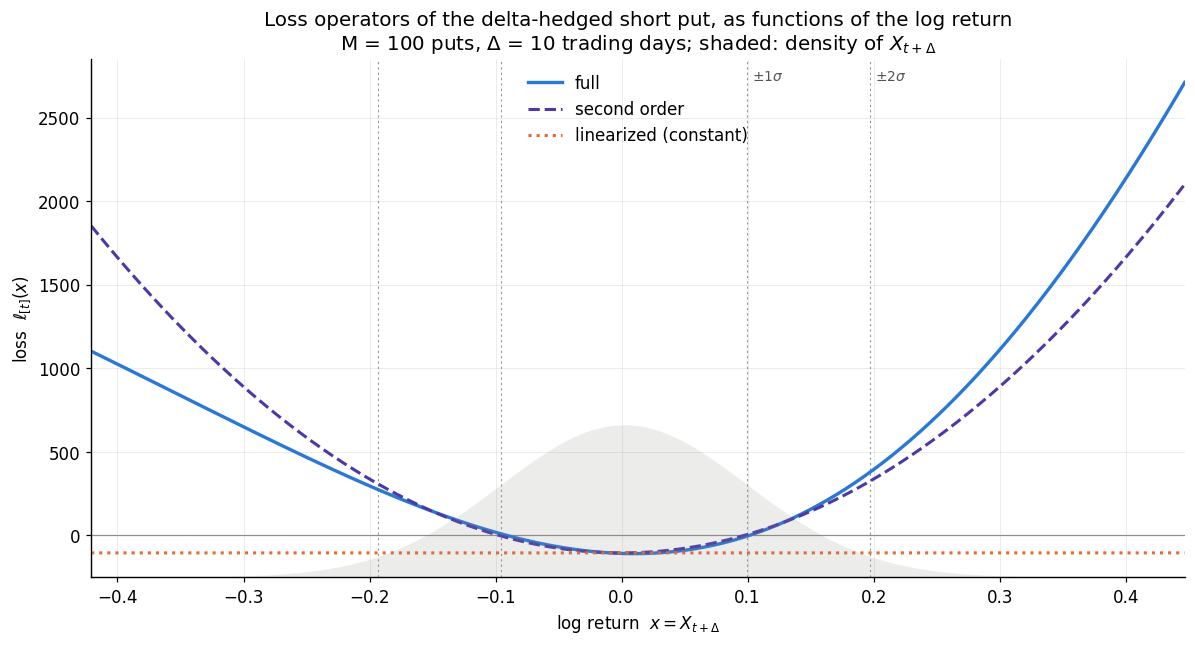

In [9]:
grid = np.linspace(X.min(), X.max(), 1200)
fig, ax = plt.subplots(figsize=(11, 6))

# density of X, shaded, on its own scale behind the curves
ax2 = ax.twinx()
dens = norm.pdf(grid, mean_x, sd_x)
ax2.fill_between(grid, dens, color=C_MUTE, alpha=0.16, zorder=0, lw=0)
ax2.set_ylim(0, dens.max() * 3.4)
ax2.set_yticks([])
ax2.grid(False)

ax.plot(grid, loss_full(grid), color=C_FULL, lw=2.2, zorder=3, label="full")
ax.plot(grid, loss_quadratic(grid), color=C_QUAD, lw=2.0, ls="--", zorder=3,
        label="second order")
ax.plot(grid, loss_linear(grid), color=C_LIN, lw=2.0, ls=":", zorder=3,
        label="linearized (constant)")
ax.axhline(0.0, color=C_INK, lw=0.8, alpha=0.5, zorder=1)

for k in (1, 2):
    for s in (-1, 1):
        ax.axvline(mean_x + s * k * sd_x, color=C_INK, lw=0.7, ls=(0, (2, 3)),
                   alpha=0.45, zorder=1)
ax.annotate(r"$\pm 1\sigma$", xy=(mean_x + sd_x, ax.get_ylim()[1]),
            xytext=(3, -14), textcoords="offset points", fontsize=9, color=C_INK, alpha=0.7)
ax.annotate(r"$\pm 2\sigma$", xy=(mean_x + 2 * sd_x, ax.get_ylim()[1]),
            xytext=(3, -14), textcoords="offset points", fontsize=9, color=C_INK, alpha=0.7)

ax.set_title("Loss operators of the delta-hedged short put, as functions of the log return\n"
             f"M = {M_OPT} puts, $\\Delta$ = {DELTA*252:.0f} trading days; "
             "shaded: density of $X_{t+\\Delta}$")
ax.set_xlabel("log return  $x = X_{t+\\Delta}$")
ax.set_ylabel("loss  $\\ell_{[t]}(x)$")
ax.set_xlim(grid[0], grid[-1])
ax.legend(loc="upper center")
fig.tight_layout()
fig.savefig(FIG1, dpi=FIG_DPI, bbox_inches="tight")
print(f"saved {FIG1.resolve()}")
plt.show()

---
## 7. Histogram approximations of the loss densities

The full and second-order losses have genuine densities and are shown as
histograms normalised to unit area. The linearized loss is a **point mass**: a
histogram of a constant is a single infinitely tall bar, so it is drawn instead as
a vertical line at $M\Delta\theta$, which is what its distribution actually is.

### Pseudocode — density comparison plot

```
1  choose common bin edges covering the full and second-order samples
2  histogram each of those two samples, normalised so the area is one
3  draw the linearized loss as a vertical line, since its law is a point mass
4  mark the 95% quantile of the full loss for reference
5  label axes and legend; save at print resolution
```

saved /tmp/hw34/loss_distributions.png


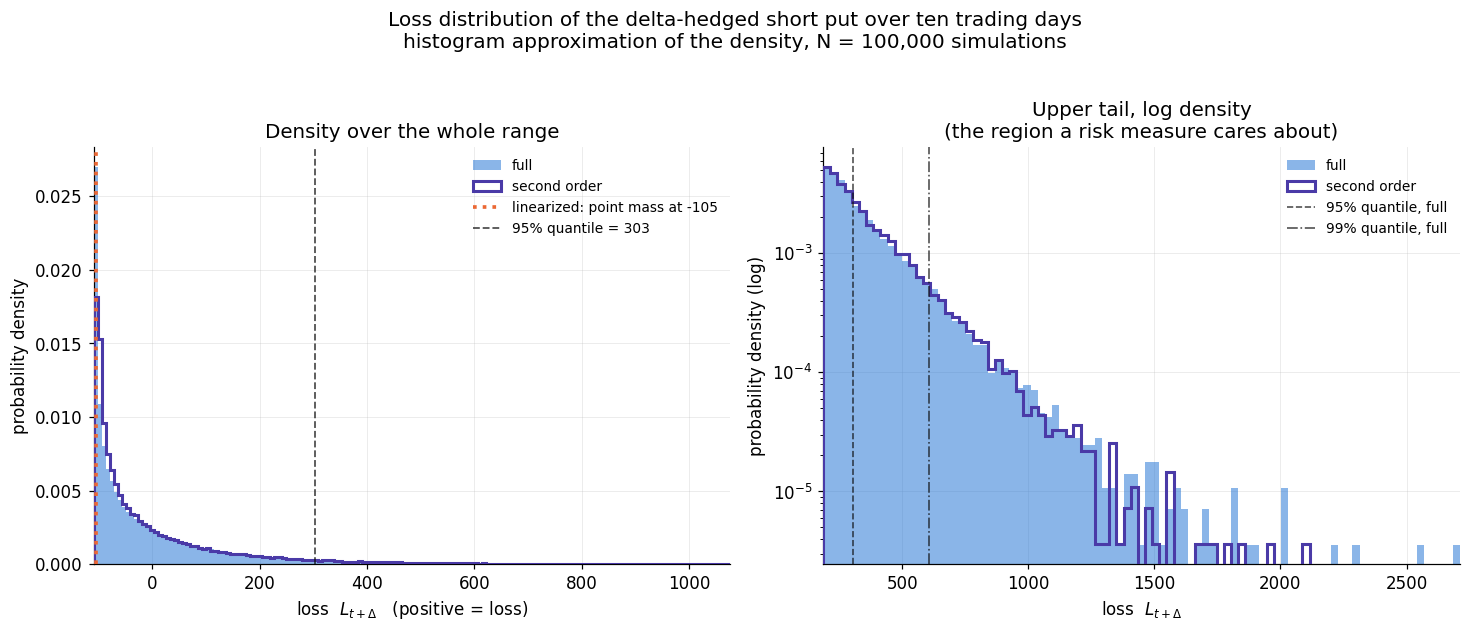

In [10]:
lo = min(L_full.min(), L_quad.min())
hi = np.percentile(np.concatenate([L_full, L_quad]), 99.9)
bins = np.linspace(lo, hi, 160)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))

# ---- left: the bulk of the distribution ------------------------------------
ax = axes[0]
ax.hist(L_full, bins=bins, density=True, color=C_FULL, alpha=0.55, label="full", zorder=2)
ax.hist(L_quad, bins=bins, density=True, histtype="step", color=C_QUAD, lw=2.0,
        label="second order", zorder=3)
ax.axvline(L_LIN_CONST, color=C_LIN, lw=2.4, ls=":", zorder=4,
           label=f"linearized: point mass at {L_LIN_CONST:.0f}")
var95 = np.percentile(L_full, 95)
ax.axvline(var95, color=C_INK, lw=1.2, ls="--", alpha=0.7, zorder=4,
           label=f"95% quantile = {var95:.0f}")
ax.set_title("Density over the whole range")
ax.set_xlabel("loss  $L_{t+\\Delta}$   (positive = loss)")
ax.set_ylabel("probability density")
ax.set_xlim(lo, hi)
ax.legend(loc="upper right", fontsize=9)

# ---- right: the upper tail, log scale --------------------------------------
ax = axes[1]
t_lo = np.percentile(L_full, 90)
t_hi = max(L_full.max(), L_quad.max())
tbins = np.linspace(t_lo, t_hi, 90)
ax.hist(L_full, bins=tbins, density=True, color=C_FULL, alpha=0.55, label="full", zorder=2)
ax.hist(L_quad, bins=tbins, density=True, histtype="step", color=C_QUAD, lw=2.0,
        label="second order", zorder=3)
for a, ls in ((0.95, "--"), (0.99, "-.")):
    ax.axvline(np.percentile(L_full, 100 * a), color=C_INK, lw=1.1, ls=ls, alpha=0.7,
               zorder=4, label=f"{a:.0%} quantile, full")
ax.set_yscale("log")
ax.set_title("Upper tail, log density\n(the region a risk measure cares about)")
ax.set_xlabel("loss  $L_{t+\\Delta}$")
ax.set_ylabel("probability density (log)")
ax.set_xlim(t_lo, t_hi)
ax.legend(loc="upper right", fontsize=9)

fig.suptitle("Loss distribution of the delta-hedged short put over ten trading days\n"
             f"histogram approximation of the density, N = {N_SIM:,} simulations", y=1.02)
fig.tight_layout()
fig.savefig(FIG2, dpi=FIG_DPI, bbox_inches="tight")
print(f"saved {FIG2.resolve()}")
plt.show()

---
## 8. How well do the approximations work?

Three ways of answering: the pointwise error in the operator, the agreement of the
distributions, and the effect on a risk number. For the last one the empirical
quantile is used, which for $n$ ordered observations is
$\widehat{\mathrm{VaR}}_\alpha=\ell_{(\lceil n\alpha\rceil)}$.

In [11]:
err_q = L_quad - L_full
err_l = L_lin - L_full
absx = np.abs(X - mean_x)

print("POINTWISE ERROR against the full loss, over the simulated sample")
print(f"  {'':<14}{'mean':>12}{'mean |err|':>13}{'max |err|':>12}{'RMSE':>12}")
for nm, e in (("second order", err_q), ("linearized", err_l)):
    print(f"  {nm:<14}{e.mean():>12.3f}{np.abs(e).mean():>13.3f}"
          f"{np.abs(e).max():>12.3f}{np.sqrt((e**2).mean()):>12.3f}")

print("\n  error of the second-order operator, by size of the move")
edges = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, np.inf]
print(f"  {'|x - mean| in sd':<20}{'share':>9}{'mean |err|':>13}{'max |err|':>12}")
for a, b in zip(edges[:-1], edges[1:]):
    m = (absx >= a * sd_x) & (absx < b * sd_x)
    if m.sum() == 0:
        continue
    lab = f"[{a:.1f}, {b:.1f})" if np.isfinite(b) else f">= {a:.1f}"
    print(f"  {lab:<20}{m.mean():>8.1%}{np.abs(err_q[m]).mean():>13.3f}"
          f"{np.abs(err_q[m]).max():>12.3f}")

off = float(loss_full(0.0) - loss_quadratic(0.0))
print(f"\n  a constant {off:.3f} of that error is the x-independent time-truncation term;")
print(f"  removing it leaves mean |error| {np.abs(err_q - off).mean():.3f},"
      f" RMSE {np.sqrt(((err_q - off)**2).mean()):.3f}")

print("\nDISTRIBUTIONAL AGREEMENT")
print(f"  correlation(full, second order)          : {np.corrcoef(L_full, L_quad)[0,1]:.6f}")
print(f"  share of trials where |error| < 1 unit   : {(np.abs(err_q) < 1).mean():.2%}")
print(f"  share of trials where |error| < 10 units : {(np.abs(err_q) < 10).mean():.2%}")
ks = np.max(np.abs(np.sort(L_full) - np.sort(L_quad)))
print(f"  largest gap between the sorted samples   : {ks:.3f}")

print("\nWHICH MOVES DRIVE THE LOSS TAIL")
for a in (0.95, 0.99):
    thr = np.percentile(L_full, 100 * a)
    tail_x = X[L_full >= thr]
    print(f"  beyond the {a:.0%} quantile: {(tail_x > 0).mean():.0%} of the trials are UP moves,"
          f" {(tail_x < 0).mean():.0%} are down moves")
print("  the hedge is short stock (lambda < 0), so a rally loses on the share leg")
print("  without bound, while a sell-off has the put's value capped at K")

print("\nRISK NUMBERS  (empirical quantile, VaR_alpha = l_(ceil(n alpha)))")


def emp_var(L, alpha):
    n = L.size
    return float(np.sort(L)[int(np.ceil(n * alpha)) - 1])


print(f"  {'alpha':>8}{'full':>12}{'second order':>15}{'linearized':>13}"
      f"{'2nd err':>11}{'lin err':>11}")
for a in (0.90, 0.95, 0.99, 0.995, 0.999):
    vf, vq, vl = emp_var(L_full, a), emp_var(L_quad, a), emp_var(L_lin, a)
    print(f"  {a:>8.3f}{vf:>12.2f}{vq:>15.2f}{vl:>13.2f}{vq-vf:>11.2f}{vl-vf:>11.2f}")

POINTWISE ERROR against the full loss, over the simulated sample
                        mean   mean |err|   max |err|        RMSE
  second order        -0.468       13.293     750.349      27.524
  linearized        -106.001      106.921    2816.004     187.605

  error of the second-order operator, by size of the move
  |x - mean| in sd        share   mean |err|   max |err|
  [0.0, 0.5)             38.3%        5.805      12.099
  [0.5, 1.0)             30.0%       11.553      12.971
  [1.0, 1.5)             18.3%        7.523      12.924
  [1.5, 2.0)              8.8%       19.506      53.941
  [2.0, 3.0)              4.3%       88.189     214.509
  >= 3.0                  0.3%      293.750     750.349

  a constant -3.229 of that error is the x-independent time-truncation term;
  removing it leaves mean |error| 13.676, RMSE 27.658

DISTRIBUTIONAL AGREEMENT
  correlation(full, second order)          : 0.984282
  share of trials where |error| < 1 unit   : 4.59%
  share of trials wher

### Reading those numbers

**The linearized operator fails completely.** It is a constant, so its loss
distribution has zero variance and its VaR is the same number at every confidence
level. It cannot see the risk of this portfolio at all, because delta-hedging has
removed exactly the exposure the linearization keeps. Reporting it as a risk
measure would say the position is riskless when it is not.

**The second-order operator works well in the middle and degrades in the tails.**
The error table by move size makes the pattern explicit: a few units for moves
inside one standard deviation, rising to hundreds beyond three.

**Where its error comes from is worth being precise about,** because it is not
simply "the next Taylor term". Section 4's operator is second order in $x$ but only
**first order in $\Delta$**, and every greek in it is frozen at time $t$. Comparing
the two operators' Taylor coefficients about $x=0$ — printed in CHECK 3 above —
shows three distinct sources:

| order in $x$ | full operator | $\ell^{\mathrm{quad}}$ | gap |
|---|---|---|---|
| constant | $M\bigl(P^{BS}(t+\Delta,S_t)-P^{BS}(t,S_t)\bigr)$ | $M\Delta\theta$ | $O(\Delta^2)$ time truncation |
| $x$ | $MS_t\bigl(\delta(t+\Delta,S_t)-\lambda\bigr)$ | $0$ | $O(\Delta)$: delta drifts as the option ages |
| $x^2$ | $\tfrac12MS_t^2\gamma(t+\Delta,S_t)+\dots$ | $\tfrac12MS_t^2\gamma(t,S_t)$ | $O(\Delta)$: gamma drifts too |

So even at $x=0$ the two disagree by a few units: the hedge is set at $t$ but the
loss is realised at $t+\Delta$, and over ten days the option's own greeks have
moved. Only for $\Delta\to0$ would the residual collapse to a pure $O(x^3)$ term.

**In the far tail the true loss is not a parabola at all, and it is asymmetric.**
Since $\lambda=\delta(t,S_t)<0$, holding $M\lambda$ shares means the hedge is
*short* the stock. The two wings therefore behave completely differently:

* **Rally ($x\gg0$).** The short put can gain at most its premium, but the short
  share position loses $-M\lambda S_t(e^{x}-1)$, which grows *exponentially*. The
  full loss outruns any parabola, so the second-order operator **understates** it.
  At $x=+0.30$ the full loss is $1110$ against $889$ for the quadratic.
* **Sell-off ($x\ll0$).** The put's value is capped at $Ke^{-r\tau}$ and the short
  shares gain, so the full loss is *bounded* — it tends to about $5002$ as
  $x\to-\infty$. The parabola keeps growing without limit, so the second-order
  operator **overstates** it. At $x=-0.30$ the full loss is $650$ against the same
  $889$.

This matters for the risk number, because the loss tail is driven by the wing where
the quadratic understates: beyond the 99% quantile, about 85% of the trials are up
moves. That is why every entry in the VaR table above has the second-order estimate
*below* the full one, and why the gap widens as $\alpha$ rises — from $-3.5$ at
$\alpha=0.95$ to $-90$ at $\alpha=0.999$. An approximation that is conservative on
the wrong side is not conservative.

---
## 9. Is $N=100{,}000$ enough? An exact cross-check

The quantiles above are Monte-Carlo estimates, so before drawing conclusions from
them it is worth asking how much of the difference between the operators is real
and how much is sampling noise. Both loss distributions can in fact be inverted
**exactly**, with no simulation at all, because each loss is an explicit function of
a single normal variable:

* **Second order.** $\ell^{\mathrm{quad}}(x)=A+Bx^{2}$ with $A=M\Delta\theta$ and
  $B=\tfrac12M\gamma S_t^{2}>0$, so for $\ell\ge A$,
  $$F(\ell)=\mathbb P\bigl(|X|\le c\bigr)=\Phi\!\left(\frac{c-m}{s}\right)-\Phi\!\left(\frac{-c-m}{s}\right),
  \qquad c=\sqrt{\frac{\ell-A}{B}},$$
  with $m,s$ the mean and standard deviation of $X_{t+\Delta}$. Solving
  $F(\ell)=\alpha$ for $\ell$ gives the exact $\mathrm{VaR}_\alpha$.

* **Full.** $\ell_{[t]}$ is U-shaped in $x$ with a single minimum, so
  $\{\ell_{[t]}(X)\le\ell\}=\{x_-(\ell)\le X\le x_+(\ell)\}$ and
  $F(\ell)=\Phi\bigl((x_+-m)/s\bigr)-\Phi\bigl((x_--m)/s\bigr)$, the two roots found
  numerically. (For $\ell$ above the left branch's supremum the set extends to
  $-\infty$ and the first term alone applies.)

Comparing these with the simulated quantiles tests the whole pipeline at once.

In [12]:
from scipy.optimize import brentq, minimize_scalar

A_q = M_OPT * DELTA * THETA0
B_q = 0.5 * M_OPT * GAMMA0 * S0 ** 2


def cdf_quad_exact(L):
    if L <= A_q:
        return 0.0
    c = np.sqrt((L - A_q) / B_q)
    return float(norm.cdf((c - mean_x) / sd_x) - norm.cdf((-c - mean_x) / sd_x))


_res = minimize_scalar(lambda x: float(loss_full(x)), bounds=(-0.5, 0.5),
                       method="bounded", options={"xatol": 1e-13})
x_min, L_min = float(_res.x), float(_res.fun)
L_left_sup = float(M_OPT * (K * np.exp(-R * TAU_1) - P0 + LAMBDA * S0))  # limit as x -> -inf


def cdf_full_exact(L):
    if L <= L_min:
        return 0.0
    xr = brentq(lambda x: float(loss_full(x)) - L, x_min, 10.0)
    if L >= L_left_sup:
        return float(norm.cdf((xr - mean_x) / sd_x))
    xl = brentq(lambda x: float(loss_full(x)) - L, -60.0, x_min)
    return float(norm.cdf((xr - mean_x) / sd_x) - norm.cdf((xl - mean_x) / sd_x))


print(f"the full loss is minimised at x = {x_min:.6f}, value {L_min:.4f}")
print(f"its left branch is bounded: as x -> -inf the loss tends to {L_left_sup:.2f}")
print(f"  (the put is worth at most K e^-r.tau and the short shares gain without limit)")

print(f"\n{'alpha':>7}  {'--- full loss ---':^34}  {'--- second order ---':^24}")
print(f"{'':>7}{'exact':>12}{'simulated':>12}{'MC 95% band':>14}{'exact':>12}{'simulated':>12}")
for a in (0.90, 0.95, 0.99, 0.995, 0.999):
    ex_f = brentq(lambda L: cdf_full_exact(L) - a, L_min + 1e-9, 8000.0)
    ex_q = brentq(lambda L: cdf_quad_exact(L) - a, A_q + 1e-12, A_q + 4 * B_q)
    mc_f, mc_q_ = emp_var(L_full, a), emp_var(L_quad, a)
    dens = (cdf_full_exact(ex_f + 0.5) - cdf_full_exact(ex_f - 0.5))
    band = 1.96 * np.sqrt(a * (1 - a) / N_SIM) / dens
    flag = "ok" if abs(ex_f - mc_f) <= band else "outside"
    print(f"{a:>7.3f}{ex_f:>12.2f}{mc_f:>12.2f}{'+/- ' + format(band, '.2f'):>14}"
          f"{ex_q:>12.2f}{mc_q_:>12.2f}   {flag}")

print("\nevery simulated quantile sits inside its Monte-Carlo confidence band,")
print("so the simulation is unbiased; the spread at alpha = 0.999 is wide simply")
print(f"because only {int(N_SIM*0.001)} of the {N_SIM:,} trials lie beyond it.")
print(f"\nexact gap (second order - full):")
for a in (0.95, 0.99, 0.999):
    ex_f = brentq(lambda L: cdf_full_exact(L) - a, L_min + 1e-9, 8000.0)
    ex_q = brentq(lambda L: cdf_quad_exact(L) - a, A_q + 1e-12, A_q + 4 * B_q)
    print(f"  alpha = {a:.3f}:  {ex_q - ex_f:+.2f}   (simulated {emp_var(L_quad,a)-emp_var(L_full,a):+.2f})")
print("the conclusion is unchanged, and the exact gap is if anything larger.")

the full loss is minimised at x = 0.009980, value -109.4373
its left branch is bounded: as x -> -inf the loss tends to 5002.12
  (the put is worth at most K e^-r.tau and the short shares gain without limit)

  alpha          --- full loss ---             --- second order ---  
              exact   simulated   MC 95% band       exact   simulated
  0.900      185.82      186.19      +/- 3.12      180.77      180.65   ok
  0.950      304.83      302.88      +/- 4.75      300.76      299.37   ok


  0.990      608.72      605.84     +/- 12.67      595.83      592.50   ok


  0.995      757.43      742.94     +/- 19.58      727.29      722.65   ok
  0.999     1146.89     1111.61     +/- 49.97     1038.71     1021.38   ok

every simulated quantile sits inside its Monte-Carlo confidence band,
so the simulation is unbiased; the spread at alpha = 0.999 is wide simply
because only 100 of the 100,000 trials lie beyond it.

exact gap (second order - full):
  alpha = 0.950:  -4.07   (simulated -3.51)


  alpha = 0.990:  -12.89   (simulated -13.34)


  alpha = 0.999:  -108.18   (simulated -90.24)
the conclusion is unchanged, and the exact gap is if anything larger.


---
## 9. Final numerical outputs

In [13]:
line = "=" * 78
print(line); print("SUMMARY OF RESULTS"); print(line)

print("\n[INPUTS]")
print(f"  mu = {MU}, sigma = {SIGMA}, r = {R}")
print(f"  t = {T_NOW}, T = {T_MAT}, Delta = {DELTA:.8f} ({DELTA*252:.0f} trading days)")
print(f"  S_t = {S0}, K = {K}, M = {M_OPT} puts, N = {N_SIM:,} trials, seed = {SEED}")

print("\n[OPTION AT t]")
print(f"  d1 = {float(_d1):.6f}     d2 = {float(_d2):.6f}")
print(f"  P^BS(t, S_t) = {P0:.6f}")
print(f"  lambda = delta = {LAMBDA:.6f}     gamma = {GAMMA0:.6f}     theta = {THETA0:.6f}")
print(f"  V_t = {V_T:.4f}")

print("\n[LOSS OPERATORS]")
print(f"  full        l(x)      = M ( P(t+Delta, S_t e^x) - P(t,S_t) - lambda S_t (e^x - 1) )")
print(f"  linearized  l_lin(x)  = M Delta theta = {L_LIN_CONST:.6f}   (constant)")
print(f"  second ord. l_quad(x) = M ( Delta theta + (1/2) gamma S_t^2 x^2 )")
print(f"                        = {L_LIN_CONST:.4f} + {0.5*M_OPT*GAMMA0*S0**2:.4f} x^2")

print("\n[LOSS DISTRIBUTION, full operator]")
print(f"  mean {L_full.mean():.2f}   sd {L_full.std(ddof=1):.2f}"
      f"   min {L_full.min():.2f}   max {L_full.max():.2f}")
print(f"  P(loss > 0) = {(L_full > 0).mean():.4f}")
for a in (0.90, 0.95, 0.99):
    print(f"  VaR_{a:.2f} = {emp_var(L_full, a):.2f}")

print("\n[ACCURACY OF THE APPROXIMATIONS]")
print(f"  second order : mean |error| {np.abs(err_q).mean():.3f},"
      f" max |error| {np.abs(err_q).max():.3f}")
print(f"  linearized   : mean |error| {np.abs(err_l).mean():.3f},"
      f" max |error| {np.abs(err_l).max():.3f}, variance 0 by construction")

print("\n[FILES]")
for f in (FIG1, FIG2):
    print(f"  {f.resolve()}  ({'exists' if f.exists() else 'MISSING'})")
print(line)

SUMMARY OF RESULTS

[INPUTS]
  mu = 0.16905, sigma = 0.4907, r = 0.0011888
  t = 0.0, T = 0.291667, Delta = 0.03968254 (10 trading days)
  S_t = 152.51, K = 170.0, M = 100 puts, N = 100,000 trials, seed = 731

[OPTION AT t]
  d1 = -0.275866     d2 = -0.540874
  P^BS(t, S_t) = 27.098960
  lambda = delta = -0.608674     gamma = 0.009502     theta = -26.466240
  V_t = -11992.7904

[LOSS OPERATORS]
  full        l(x)      = M ( P(t+Delta, S_t e^x) - P(t,S_t) - lambda S_t (e^x - 1) )
  linearized  l_lin(x)  = M Delta theta = -105.024763   (constant)
  second ord. l_quad(x) = M ( Delta theta + (1/2) gamma S_t^2 x^2 )
                        = -105.0248 + 11050.7905 x^2

[LOSS DISTRIBUTION, full operator]
  mean 0.98   sd 154.79   min -109.44   max 2710.98
  P(loss > 0) = 0.3240
  VaR_0.90 = 186.19
  VaR_0.95 = 302.88
  VaR_0.99 = 605.84

[ACCURACY OF THE APPROXIMATIONS]
  second order : mean |error| 13.293, max |error| 750.349
  linearized   : mean |error| 106.921, max |error| 2816.004, vari

---
## 10. Self-checks

In [14]:
checks = []


def check(name, ok):
    checks.append((name, bool(ok)))


def same(a, b, rtol=1e-10):
    a, b = float(a), float(b)
    return abs(a - b) <= rtol * max(abs(a), abs(b), 1e-300)


# option and greeks
check("put price matches K e^-r.tau N(-d2) - S N(-d1)",
      same(P0, float(K * np.exp(-R * TAU_0) * norm.cdf(-_d2) - S0 * norm.cdf(-_d1))))
check("put price above intrinsic value", P0 >= max(K - S0, 0.0) * np.exp(-R * TAU_0) - 1e-9)
check("delta of a put lies in (-1, 0)", -1.0 < LAMBDA < 0.0)
check("gamma positive", GAMMA0 > 0)
check("lambda equals delta at (t, S_t)", same(LAMBDA, float(put_delta(TAU_0, S0))))

# operators
check("hedge kills the first-order term", abs(float(fz)) < 1e-4 * abs(V_T))
check("f_zz equals -M gamma S^2", abs(float(fzz2) / (-M_OPT * GAMMA0 * S0 ** 2) - 1) < 1e-4)
check("linearized operator is constant in x", float(np.ptp(loss_linear(grid))) == 0.0)
check("linearized equals M Delta theta", same(L_LIN_CONST, M_OPT * DELTA * THETA0))
check("quadratic equals linearized at x = 0", same(float(loss_quadratic(0.0)), L_LIN_CONST))
check("quadratic is symmetric in x",
      same(float(loss_quadratic(0.07)), float(loss_quadratic(-0.07))))
check("quadratic increases away from x = 0",
      float(loss_quadratic(0.10)) > float(loss_quadratic(0.05)) > float(loss_quadratic(0.0)))
check("full operator has a non-zero x coefficient (delta drifts over the horizon)",
      abs(c1) > 1.0 and same(c1, M_OPT * S0 * (delta_1 - LAMBDA), rtol=1e-4))
check("the residual at x = 0 is the time-truncation error",
      same(c0 - L_LIN_CONST,
           M_OPT * (float(put_price(TAU_1, S0)) - P0) - M_OPT * DELTA * THETA0, rtol=1e-9))
check("full operator reproduces the portfolio value change",
      same(float(loss_full(0.123)),
           -(M_OPT * (LAMBDA * S0 * np.exp(0.123) - float(put_price(TAU_1, S0 * np.exp(0.123))))
             - V_T)))

# simulation
check(f"exactly N = {N_SIM:,} trials", X.size == N_SIM and L_full.size == N_SIM)
check("X has the right mean", abs(X.mean() - mean_x) < 5 * sd_x / np.sqrt(N_SIM))
check("X has the right sd", abs(X.std(ddof=1) / sd_x - 1) < 0.02)
check("all three loss samples are finite",
      bool(np.all(np.isfinite(L_full)) and np.all(np.isfinite(L_quad))
           and np.all(np.isfinite(L_lin))))
check("linearized sample has zero spread", float(np.ptp(L_lin)) == 0.0)
check("simulation reproducible from the seed",
      np.allclose(np.random.default_rng(SEED).normal(mean_x, sd_x, N_SIM), X))

# risk numbers
check("empirical VaR increases with alpha",
      emp_var(L_full, 0.90) < emp_var(L_full, 0.95) < emp_var(L_full, 0.99))
check("linearized VaR is flat in alpha",
      same(emp_var(L_lin, 0.90), emp_var(L_lin, 0.999)))

# files
check("loss_operators.png written", FIG1.exists())
check("loss_distributions.png written", FIG2.exists())

width = max(len(n) for n, _ in checks) + 2
for name, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {name:<{width}}")
failed = [n for n, ok in checks if not ok]
print("\n" + ("ALL CHECKS PASSED" if not failed else f"{len(failed)} CHECK(S) FAILED: {failed}"))
assert not failed

  PASS  put price matches K e^-r.tau N(-d2) - S N(-d1)                              
  PASS  put price above intrinsic value                                             
  PASS  delta of a put lies in (-1, 0)                                              
  PASS  gamma positive                                                              
  PASS  lambda equals delta at (t, S_t)                                             
  PASS  hedge kills the first-order term                                            
  PASS  f_zz equals -M gamma S^2                                                    
  PASS  linearized operator is constant in x                                        
  PASS  linearized equals M Delta theta                                             
  PASS  quadratic equals linearized at x = 0                                        
  PASS  quadratic is symmetric in x                                                 
  PASS  quadratic increases away from x = 0                      